# AlphaSearchBench 실험 검증 노트북 (v2)

**용도**: 결과 탐색을 넘어 *실험 주장 검증* — 공정성(integrity) → 성능 →
일반화 → QD → 통계 → 자동 일관성 검사 순.

**test 봉인 원칙**: 전역 scaler/PCA/bin 경계는 **valid descriptor로만 fit**하고
test는 transform/사후확인 전용. niche 품질 음영은 valid 기준.

| 섹션 | 내용 |
|---|---|
| §2 | 실험 integrity/comparability 표 + leakage assertion |
| §3 | 대표 요약표 (factor 평균 vs pool 결합 — 두 층위 분리) |
| §4 | 최종 모델(pool) test 누적수익 백테스트 |
| §5 | Validity / search 효율 |
| §6 | OOS 일반화 (train→valid→test, ΔIC 주지표) |
| §7 | Final-Pool QD 공용 좌표계 (valid-fit PCA, 시각화 전용) |
| §8 | 원시 descriptor niche grid ×5 (global valid 분위 bin) |
| §9 | Search-QD (budget 정규화 축) |
| §10 | 계층적 통계 비교 (n_seeds에 따라 자동 강등) |
| §11 | Robustness assertions (실패 시 노트북 에러) |
| §12 | 해석·한계 |


In [13]:
# ---------------- §0 Configuration / run registry ----------------
from pathlib import Path

def _find_asb_root(start: Path) -> Path:
    p = start.resolve()
    while p.name != "AlphaSearchBench" and p.parent != p:
        p = p.parent
    assert p.name == "AlphaSearchBench", "AlphaSearchBench 루트를 찾지 못했습니다"
    return p

ASB_ROOT = _find_asb_root(Path.cwd())
GP = ASB_ROOT / "gplearn_asb" / "out"
AA = ASB_ROOT / "AlphaAgent_asb" / "out"

# 각 run: asb(ASB evaluate 출력) / miner(마이너 자체 출력, 없으면 None) /
#         group(통계 집계 단위 — seed가 다른 같은 method는 같은 group)
RUNS_REGISTRY = {
    "gp_off":    {"asb": GP / "pilot_csi800_off_42" / "asb_eval",
                  "miner": GP / "pilot_csi800_off_42",    "group": "gp_off"},
    "gp_hard":   {"asb": GP / "pilot_csi800_hard_42" / "asb_eval",
                  "miner": GP / "pilot_csi800_hard_42",   "group": "gp_hard"},
    "gp_strict": {"asb": GP / "pilot_csi800_strict_42" / "asb_eval",
                  "miner": GP / "pilot_csi800_strict_42", "group": "gp_strict"},
    "aa_expB":   {"asb": AA / "alphaagent_asb_expB_csi800" / "asb_eval",
                  "miner": AA / "alphaagent_asb_expB_csi800", "group": "aa_expB"},
    # 구 pilot (market=all 등 조건이 달라 integrity 표에서 분리 확인됨):
    # "gp_smoke_legacy": {"asb": ASB_ROOT/"out"/"pilot"/"gp_smoke", "miner": None, "group": "gp_smoke_legacy"},
}
SELECTED_RUN = "gp_strict"          # 단일-run 상세 그래프 대상
RETENTION_CUTOFF = 0.01             # §6 retention 계산 최소 |valid_IC| (사전 고정)
NICHE_BINS = 3                      # §8 축당 분위 bin 수 (소표본 pilot 기준)
print("ASB_ROOT =", ASB_ROOT)


ASB_ROOT = /gpfs/home1/sku07891/00.hojin/AlphaEval/AlphaSearchBench


## §1 Loader / schema checks

로딩 실패·필수 컬럼 누락은 여기서 즉시 드러난다. 재로딩 결정론도 검사한다.

In [14]:
# ---------------- §1 로더·팔레트·스타일 (+schema check) ----------------
import json as _json
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from glob import glob
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_colwidth", 60)

for _fp in (sorted(glob("/usr/share/fonts/google-noto-cjk/NotoSansCJK-Regular.ttc"))
            or sorted(glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True))):
    try:
        fm.fontManager.addfont(_fp); break
    except Exception:
        pass
_CJK = next((f.name for f in fm.fontManager.ttflist if "Noto Sans CJK" in f.name), None)

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e87ba4", "#008300"]
MARKERS = ["o", "s", "^", "D", "v", "P"]
STATUS_BAD = "#e34948"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4df"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#dbe9f9", "#2a78d6", "#123c6b"])
DIV = LinearSegmentedColormap.from_list("div_rb", ["#e34948", "#b8b7b0", "#2a78d6"])
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "axes.unicode_minus": False,
    "font.family": ([_CJK] if _CJK else []) + ["DejaVu Sans"],
})

def short(f, n=42):
    f = str(f)
    return f if len(f) <= n else f[: n - 1] + "…"

def pshort(f, n=42):
    return short(f, n).replace("$", r"\$")

def spread_ys(ys, min_gap):
    ys = np.asarray(ys, dtype=float); out = ys.copy()
    order = np.argsort(ys)[::-1]
    for a, b in zip(order[:-1], order[1:]):
        if out[a] - out[b] < min_gap:
            out[b] = out[a] - min_gap
    return out

METRIC_TABLES = ["validity_factor_metrics", "oos_factor_metrics", "oos_pool_metrics",
                 "qd_factor_descriptors", "qd_pool_metrics",
                 "backtest_factor_metrics", "backtest_pool_metrics"]
REQUIRED_COLS = {
    "oos_factor_metrics": {"formula", "valid", "kind"},
    "qd_factor_descriptors": {"formula", "valid_IC_1d", "horizon"},
    "backtest_pool_metrics": {"AnnRet_arith", "CAGR", "Sharpe", "MDD"},
}

def load_table(d, name, sub="metrics"):
    base = Path(d) / sub / name
    for ext in (".parquet", ".pkl"):
        p = base.with_suffix(ext)
        if p.exists():
            return pd.read_parquet(p) if ext == ".parquet" else pd.read_pickle(p)
    return pd.DataFrame()

def load_run(entry):
    d = entry["asb"]
    r = {k: load_table(d, k) for k in METRIC_TABLES}
    r["qd_generation_metrics"] = load_table(d, "qd_generation_metrics")
    r["oos_daily"] = load_table(d, "oos_daily", "daily")
    r["bt_daily"] = load_table(d, "backtest_daily", "daily")
    mans = sorted(Path(d, "manifests").glob("run_*.json"))
    r["manifest"] = _json.loads(mans[-1].read_text()) if mans else {}
    r["miner_manifest"], r["miner_gen_stats"] = {}, pd.DataFrame()
    if entry.get("miner"):
        mm = sorted(Path(entry["miner"], "manifests").glob("run_*.json"))
        if mm:
            r["miner_manifest"] = _json.loads(mm[-1].read_text())
        gs = (list(Path(entry["miner"], "metrics").glob("generation_stats_*"))
              + list(Path(entry["miner"], "metrics").glob("round_stats_*")))
        if gs:
            r["miner_gen_stats"] = (pd.read_parquet(gs[0]) if gs[0].suffix == ".parquet"
                                    else pd.read_csv(gs[0]))
    return r

RUNS, SKIPPED = {}, []
for name, entry in RUNS_REGISTRY.items():
    if not Path(entry["asb"]).exists():
        SKIPPED.append(name); continue
    RUNS[name] = load_run(entry)
    RUNS[name]["group"] = entry["group"]
assert RUNS, "로드된 run이 없습니다 — RUNS_REGISTRY 경로 확인"
if SKIPPED:
    print(f"[알림] 미존재로 건너뜀: {SKIPPED}")

# schema check + 재로딩 결정론 (§11f의 1차)
for name, r in RUNS.items():
    for t, need in REQUIRED_COLS.items():
        missing = need - set(r[t].columns)
        assert not missing, f"{name}/{t} 필수 컬럼 누락: {missing}"
_r2 = load_run(RUNS_REGISTRY[list(RUNS)[0]])
pd.testing.assert_frame_equal(RUNS[list(RUNS)[0]]["oos_factor_metrics"],
                              _r2["oos_factor_metrics"])
print("로드:", ", ".join(RUNS), "| schema·결정론 검사 통과")

RUN_COLOR = {n: CAT[i % len(CAT)] for i, n in enumerate(RUNS)}
RUN_MARKER = {n: MARKERS[i % len(MARKERS)] for i, n in enumerate(RUNS)}
RUN_LS = {n: ["-", "--", "-.", ":"][i % 4] for i, n in enumerate(RUNS)}

def pool_row(r, table):
    df = r[table]
    if df.empty:
        return None
    k = df[df.get("kind", pd.Series(dtype=str)) == "pool"] if "kind" in df.columns else df
    return k.iloc[0] if len(k) else df.iloc[0]

def pget(r, table, key):
    pr = pool_row(r, table)
    return np.nan if pr is None else pr.get(key, np.nan)

def factor_rows(r, table):
    df = r[table]
    if df.empty:
        return df
    if "kind" in df.columns:
        df = df[df["kind"] == "individual"]
    return df


[알림] 미존재로 건너뜀: ['aa_expB']
로드: gp_off, gp_hard, gp_strict | schema·결정론 검사 통과


## §2 ★ Experiment integrity / comparability

method 차이를 guidance에 귀속하려면 아래 공정성 조건이 먼저 성립해야 한다.
**budget 열에 주의**: 후보 수 ≠ LLM 콜 수 (AlphaAgent는 두 축이 다름).

Metric semantics (모든 표에서 동일): `IC = mean(일별 cross-sectional Pearson,
PIT universe mask)`, `Sharpe = mean(net daily)/std(net daily, ddof=1)×√252`,
`CAGR = (1+누적net)^(252/n)−1`, `AnnRet_arith = mean(net daily)×252`,
`MDD = 최대낙폭 크기(양수)`.

In [15]:
# ---------------- §2 integrity 표 + leakage assertions ----------------
rows = []
for name, r in RUNS.items():
    m, mm = r["manifest"], r["miner_manifest"]
    of = factor_rows(r, "oos_factor_metrics")
    v = r["validity_factor_metrics"]
    eng = (of["signal_engine"].value_counts().to_dict()
           if "signal_engine" in of.columns else {})
    budget = mm.get("budget", {})
    sw = mm.get("search_window") or [None, None]
    splits = m.get("splits", {})
    rows.append({
        "run": name,
        "market": m.get("market"),
        "universe_hash": (mm.get("universe_hash") or m.get("dataset", {}).get("dataset_version", ""))[:10],
        "mining window": f"{sw[0]}~{sw[1]}" if sw[0] else "(manifest 없음)",
        "train/valid/test": " | ".join(f"{k}:{v_[0][:4]}-{v_[1][:4]}"
                                       for k, v_ in splits.items()) if splits else "?",
        "DSL(signal_engine 실측)": ", ".join(f"{k}:{v_}" for k, v_ in eng.items()) or "-",
        "attempted evals": budget.get("total_evaluations") or budget.get("n_candidate_rounds"),
        "unique evals": budget.get("unique_evaluations"),
        "LLM calls": budget.get("n_total_llm_calls", "-"),
        "seed(s)": mm.get("seed", m.get("seed")),
        "pool n(valid/전체)": f"{int(of['valid'].sum()) if 'valid' in of else '?'}/{len(v)}",
        "train_sign 출처": ("restored" if of.get("train_sign_restored", pd.Series(dtype=bool)).any()
                          else "input(마이닝 창)") if len(of) else "?",
        "constraint": mm.get("constraint_mode", "-"),
        "compat": mm.get("compatibility_mode", "-"),
        "weights": m.get("run", {}).get("weights_source"),
    })
INTEG = pd.DataFrame(rows).set_index("run")
display(INTEG)

# leakage assertions (§2 계약)
for name, r in RUNS.items():
    m, mm = r["manifest"], r["miner_manifest"]
    test_start = m.get("splits", {}).get("test", [None])[0]
    sw = (mm.get("search_window") or [None, None])
    if sw[1] and test_start:
        assert str(sw[1]) < str(test_start), \
            f"{name}: 마이닝 창({sw[1]})이 test 시작({test_start})과 겹침 — LEAKAGE"
    tsr = m.get("train_sign_rule")
    assert tsr in (None, "sign_of_signed_train_IC"), f"{name}: train_sign_rule={tsr}"
print("leakage assertion 통과: 마이닝 창 ∩ test = ∅, train-only sign rule")


,market,universe_hash,mining window,train/valid/test,DSL(signal_engine 실측),attempted evals,unique evals,LLM calls,seed(s),pool n(valid/전체),train_sign 출처,constraint,compat,weights
run,,,,,,,,,,,,,,
gp_off,csi800,23c5105bb3,2010-01-01~2019-12-31,train:2010-2016 | valid:2017-2019 | test:2021-2024,formula_engine:3,5000,1675,-,42,3/3,input(마이닝 창),off,-,equal_default
gp_hard,csi800,23c5105bb3,2010-01-01~2019-12-31,train:2010-2016 | valid:2017-2019 | test:2021-2024,formula_engine:3,5000,1675,-,42,3/3,input(마이닝 창),hard_penalty,-,equal_default
gp_strict,csi800,23c5105bb3,2010-01-01~2019-12-31,train:2010-2016 | valid:2017-2019 | test:2021-2024,formula_engine:10,5000,1635,-,42,10/10,input(마이닝 창),strict_penalty,-,equal_default


leakage assertion 통과: 마이닝 창 ∩ test = ∅, train-only sign rule


## §3 ★ Main result table

**두 층위를 분리**: `factor 평균` = pool 구성 factor 지표의 평균(합성≠평균 주의),
`pool 결합` = frozen weights로 결합한 최종 모델의 지표. IC 계열은 test(oriented).

In [16]:
# ---------------- §3 요약표 ----------------
OOS_COLS = ["IC", "RankIC", "ICIR", "RankICIR"]
BT_COLS = ["AnnRet_arith", "CAGR", "Sharpe", "MDD"]
rows = []
for name, r in RUNS.items():
    of = factor_rows(r, "oos_factor_metrics")
    bf = factor_rows(r, "backtest_factor_metrics")
    ok_o = of[of["valid"] == True] if "valid" in of else of          # noqa: E712
    ok_b = bf[bf["valid"] == True] if "valid" in bf else bf          # noqa: E712
    op, bp = pool_row(r, "oos_pool_metrics"), pool_row(r, "backtest_pool_metrics")
    row = {"run": name, "group": r["group"], "n_valid_factors": len(ok_o)}
    for c in OOS_COLS:
        row[f"f̄ {c}"] = ok_o[c].mean() if c in ok_o and len(ok_o) else np.nan
        row[f"pool {c}"] = op.get(c, np.nan) if op is not None else np.nan
    for c in BT_COLS:
        row[f"f̄ {c}"] = ok_b[c].mean() if c in ok_b and len(ok_b) else np.nan
        row[f"pool {c}"] = bp.get(c, np.nan) if bp is not None else np.nan
    rows.append(row)
MAIN = pd.DataFrame(rows).set_index("run")

n_seeds = MAIN.groupby("group").size()
if (n_seeds < 3).all():
    print("⚠️  n_seeds=%d — 기술 통계만 표시 (검정·CI 불가). seed sweep 후 재실행." %
          int(n_seeds.max()))
fmt_cols = [c for c in MAIN.columns if c not in ("group", "n_valid_factors")]
display(MAIN.style.format("{:+.4f}", subset=fmt_cols, na_rep="—")
        .background_gradient(subset=[c for c in fmt_cols if c.endswith(" IC")],
                             cmap=DIV, vmin=-0.05, vmax=0.05))


⚠️  n_seeds=1 — 기술 통계만 표시 (검정·CI 불가). seed sweep 후 재실행.


,group,n_valid_factors,f̄ IC,pool IC,f̄ RankIC,pool RankIC,f̄ ICIR,pool ICIR,f̄ RankICIR,pool RankICIR,f̄ AnnRet_arith,pool AnnRet_arith,f̄ CAGR,pool CAGR,f̄ Sharpe,pool Sharpe,f̄ MDD,pool MDD
run,,,,,,,,,,,,,,,,,,
gp_off,gp_off,3,+0.0168,+0.0003,+0.0153,+0.0017,+0.0313,+0.0095,+0.0289,+0.0473,-0.0708,-0.0661,-0.0777,-0.0741,-0.4833,-0.4479,+0.4449,+0.4451
gp_hard,gp_hard,3,+0.0168,+0.0003,+0.0153,+0.0017,+0.0313,+0.0095,+0.0289,+0.0473,-0.0708,-0.0661,-0.0777,-0.0741,-0.4833,-0.4479,+0.4449,+0.4451
gp_strict,gp_strict,10,+0.0095,+0.0095,-0.0141,-0.0152,+0.1130,+0.1151,-0.0999,-0.1106,-0.2690,-0.2686,-0.2376,-0.2372,-4.1407,-4.2022,+0.6542,+0.6543


## §4 ★ Final model backtest — pool 결합(최종 모델)의 test 누적 net return

weights는 manifest `weights_source` 기준(equal_default면 참고용).

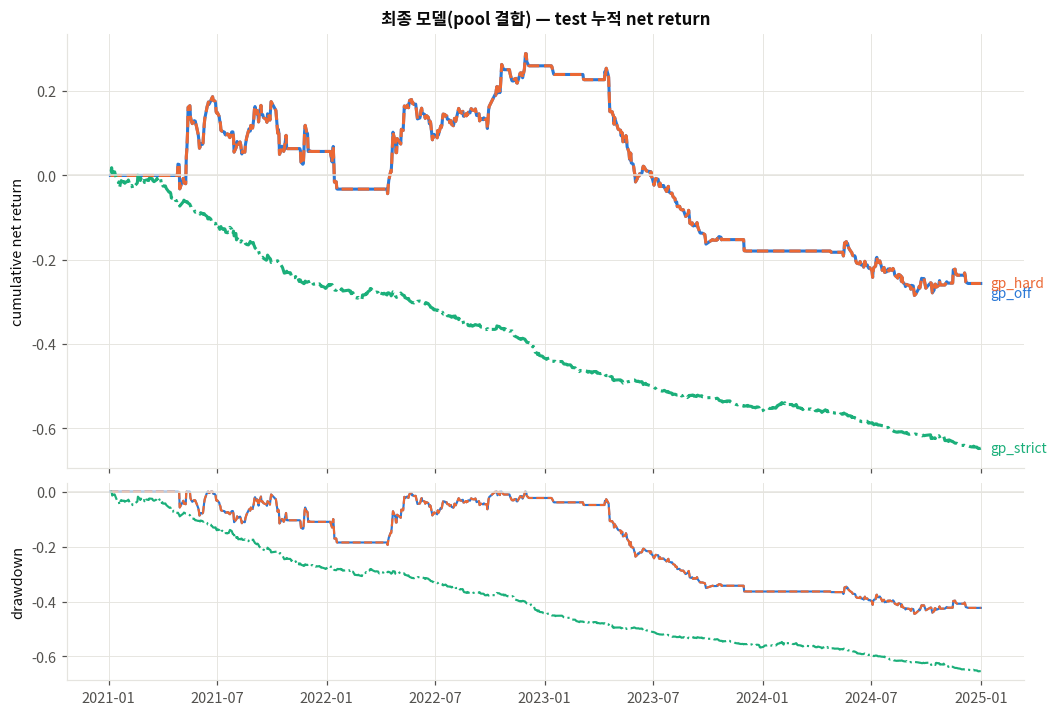

,Sharpe,CAGR,MDD,annualized_turnover_oneway
gp_off,-0.448,-0.074,+0.445,+96.318
gp_hard,-0.448,-0.074,+0.445,+96.318
gp_strict,-4.202,-0.237,+0.654,+175.207


In [17]:
# ---------------- §4 pool 누적수익 + drawdown + 지표 바 ----------------
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                         constrained_layout=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
ends = []
for name, r in RUNS.items():
    bd = r["bt_daily"]
    if bd.empty:
        continue
    pid = f"{r['manifest'].get('run', {}).get('method', '?')}:{r['manifest'].get('run', {}).get('seed', '?')}"
    g = bd[bd["formula_id"] == pid].sort_values("date")
    if g.empty:                                   # pool row 명칭 탐색 fallback
        cand = [x for x in bd["formula_id"].unique() if ":" in str(x)]
        g = bd[bd["formula_id"] == cand[0]].sort_values("date") if cand else g
    if g.empty:
        continue
    dt = pd.to_datetime(g["date"])
    cum = (1 + g["net_return"].fillna(0)).cumprod() - 1
    axes[0].plot(dt, cum, lw=2, color=RUN_COLOR[name], ls=RUN_LS[name])
    ends.append((dt.iloc[-1], cum.iloc[-1], name, RUN_COLOR[name]))
    eq = 1 + cum
    dd = eq / eq.cummax() - 1
    axes[1].plot(dt, dd, lw=1.4, color=RUN_COLOR[name], ls=RUN_LS[name])
if ends:
    span = (max(e[1] for e in ends) - min(e[1] for e in ends)) or 1.0
    for (ex, ey, nm, c), ly in zip(ends, spread_ys([e[1] for e in ends], 0.06 * span)):
        axes[0].annotate(nm, (ex, ly), xytext=(6, 0), textcoords="offset points",
                         color=c, fontsize=9, va="center", annotation_clip=False)
axes[0].axhline(0, color=GRID, lw=1)
axes[0].set_ylabel("cumulative net return")
axes[0].set_title("최종 모델(pool 결합) — test 누적 net return")
axes[0].margins(x=0.12)
axes[1].axhline(0, color=GRID, lw=1)
axes[1].set_ylabel("drawdown")
plt.show()

bt_bar = pd.DataFrame({name: {c: pget(r, "backtest_pool_metrics", c)
                              for c in ["Sharpe", "CAGR", "MDD",
                                        "annualized_turnover_oneway"]}
                       for name, r in RUNS.items()}).T
display(bt_bar.style.format("{:+.3f}", na_rep="—"))


## §5 Validity / search efficiency

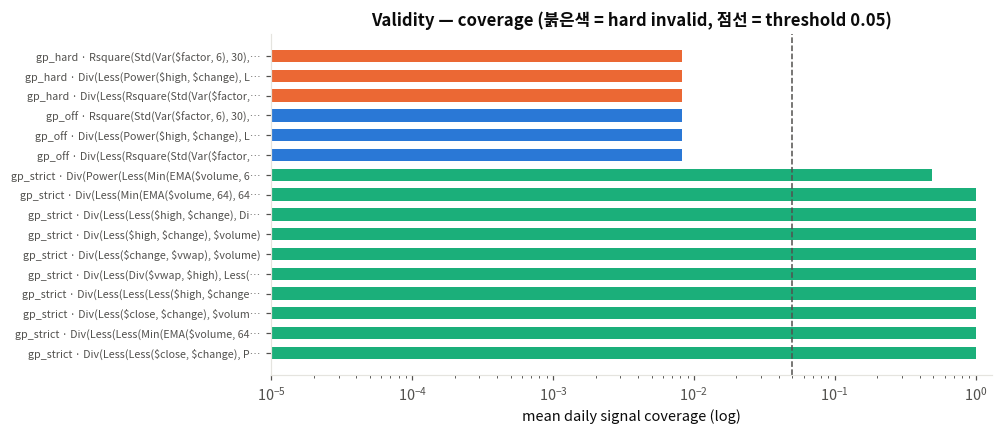

,attempted,unique,pool_valid,valid_per_1k_evals
run,,,,
gp_off,5000.00,1675.00,3.00,0.60
gp_hard,5000.00,1675.00,3.00,0.60
gp_strict,5000.00,1635.00,10.00,2.00


In [18]:
# ---------------- §5 coverage barh + 탐색 효율 ----------------
vt = []
for name, r in RUNS.items():
    v = r["validity_factor_metrics"].copy()
    v.insert(0, "run", name)
    vt.append(v)
VAL = pd.concat(vt, ignore_index=True)
d = VAL.sort_values(["run", "mean_daily_coverage_ratio"]).reset_index(drop=True)
labels = d["run"] + " · " + d["formula"].map(lambda f: pshort(f, 34))
colors = [STATUS_BAD if not ok else RUN_COLOR[rn]
          for ok, rn in zip(d.get("hard_valid", d["valid"]), d["run"])]
x = d["mean_daily_coverage_ratio"].clip(lower=1e-5)
fig, ax = plt.subplots(figsize=(9, max(3.2, 0.24 * len(d))), constrained_layout=True)
ax.barh(range(len(d)), x, color=colors, height=0.62)
ax.set_yticks(range(len(d)), labels, fontsize=7)
ax.set_xscale("log"); ax.set_xlim(1e-5, 1.3)
ax.axvline(0.05, color=INK2, lw=1, ls="--")
ax.set_xlabel("mean daily signal coverage (log)")
ax.set_title("Validity — coverage (붉은색 = hard invalid, 점선 = threshold 0.05)")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.invert_yaxis()
plt.show()

# 탐색 효율: budget 대비 valid 산출 (miner 통계가 있는 run만)
eff = []
for name, r in RUNS.items():
    b = r["miner_manifest"].get("budget", {})
    tot = b.get("total_evaluations") or b.get("n_candidate_rounds")
    of = factor_rows(r, "oos_factor_metrics")
    nv = int(of["valid"].sum()) if "valid" in of and len(of) else np.nan
    if tot:
        eff.append({"run": name, "attempted": tot,
                    "unique": b.get("unique_evaluations", np.nan),
                    "pool_valid": nv,
                    "valid_per_1k_evals": 1000 * nv / tot})
if eff:
    display(pd.DataFrame(eff).set_index("run").style.format("{:.2f}", na_rep="—"))


## §6 ★ OOS generalization (train → valid → test)

- **주지표 ΔIC = IC_test − IC_valid** (둘 다 oriented)
- retention = IC_test/IC_valid 은 |IC_valid| ≥ 0.01 인 factor에서만 (보조)
- sign-preservation = 1[sign(valid)==sign(test)]
- pool-level valid IC는 미저장 → factor-level만. selection은 train/valid까지만
  보고 test는 hold-out임이 §2에서 assert됨.

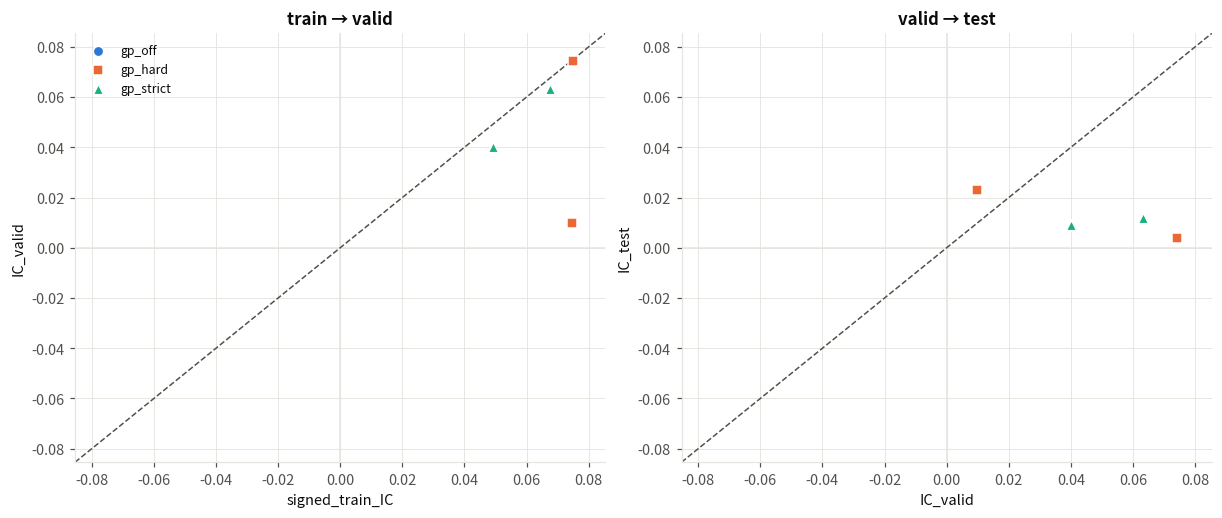

,n,mean_dIC,median_dIC,mean_retention,n_retention_eligible,sign_preservation_rate
run,,,,,,
gp_hard,3,-0.0145,+0.0133,+0.05,1,100%
gp_off,3,-0.0145,+0.0133,+0.05,1,100%
gp_strict,10,-0.0329,-0.0308,+0.23,10,100%


In [19]:
# ---------------- §6 valid→test 일반화 ----------------
gen_rows = []
for name, r in RUNS.items():
    of = factor_rows(r, "oos_factor_metrics")
    qd = r["qd_factor_descriptors"]
    if of.empty or qd.empty:
        continue
    j = of.merge(qd[["formula", "valid_IC_1d"]], on="formula", how="left")
    j = j[j["valid"] == True]                                        # noqa: E712
    for _, x in j.iterrows():
        v, t = x.get("valid_IC_1d", np.nan), x.get("IC", np.nan)
        gen_rows.append({"run": name, "formula": x["formula"],
                         "signed_train_IC": x.get("signed_train_IC"),
                         "IC_valid": v, "IC_test": t,
                         "dIC": t - v if np.isfinite(v) and np.isfinite(t) else np.nan,
                         "retention": (t / v) if (np.isfinite(v) and abs(v) >= RETENTION_CUTOFF
                                                  and np.isfinite(t)) else np.nan,
                         "sign_preserved": (np.sign(v) == np.sign(t))
                         if np.isfinite(v) and np.isfinite(t) and v != 0 else np.nan})
GEN = pd.DataFrame(gen_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
lim = max(0.02, np.nanmax(np.abs(GEN[["IC_valid", "IC_test"]].to_numpy())) * 1.15) if len(GEN) else 0.05
for ax, (xc, yc, ttl) in zip(axes, [("signed_train_IC", "IC_valid", "train → valid"),
                                    ("IC_valid", "IC_test", "valid → test")]):
    ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
    ax.plot([-lim, lim], [-lim, lim], ls="--", lw=1, color=INK2)
    for name in RUNS:
        g = GEN[GEN["run"] == name]
        if g.empty:
            continue
        ax.scatter(g[xc], g[yc], s=46, color=RUN_COLOR[name],
                   marker=RUN_MARKER[name], edgecolor="white", lw=1, label=name, zorder=3)
    ax.set_xlabel(xc); ax.set_ylabel(yc); ax.set_title(ttl)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
axes[0].legend(loc="upper left", fontsize=8)
plt.show()

if len(GEN):
    summ = GEN.groupby("run").agg(
        n=("formula", "size"),
        mean_dIC=("dIC", "mean"), median_dIC=("dIC", "median"),
        mean_retention=("retention", "mean"),
        n_retention_eligible=("retention", lambda s: int(s.notna().sum())),
        sign_preservation_rate=("sign_preserved", "mean"))
    display(summ.style.format({"mean_dIC": "{:+.4f}", "median_dIC": "{:+.4f}",
                               "mean_retention": "{:+.2f}",
                               "sign_preservation_rate": "{:.0%}"}, na_rep="—"))


## §7 ★ Final-Pool QD — 공용 좌표계 (시각화 전용)

- 좌표계: **전 run의 `valid_*` 원시 6D(H,V,M,L,B,R)** 를 z-score → PCA **fit**
  (test 정보 미사용 — §11e에서 구조적으로 assert). test 좌표는 transform만.
- **PCA는 그림용** — coverage/niche 통계는 §8의 원시 공간 grid에서 계산.
- 화살표 = PCA 로딩(축 해석), 회색 선 = valid→test drift.

공용 PCA fit: 16점(valid), 설명분산 [0.75 0.2 ]


/home1/sku07891/miniconda3/envs/AlphaEval38/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


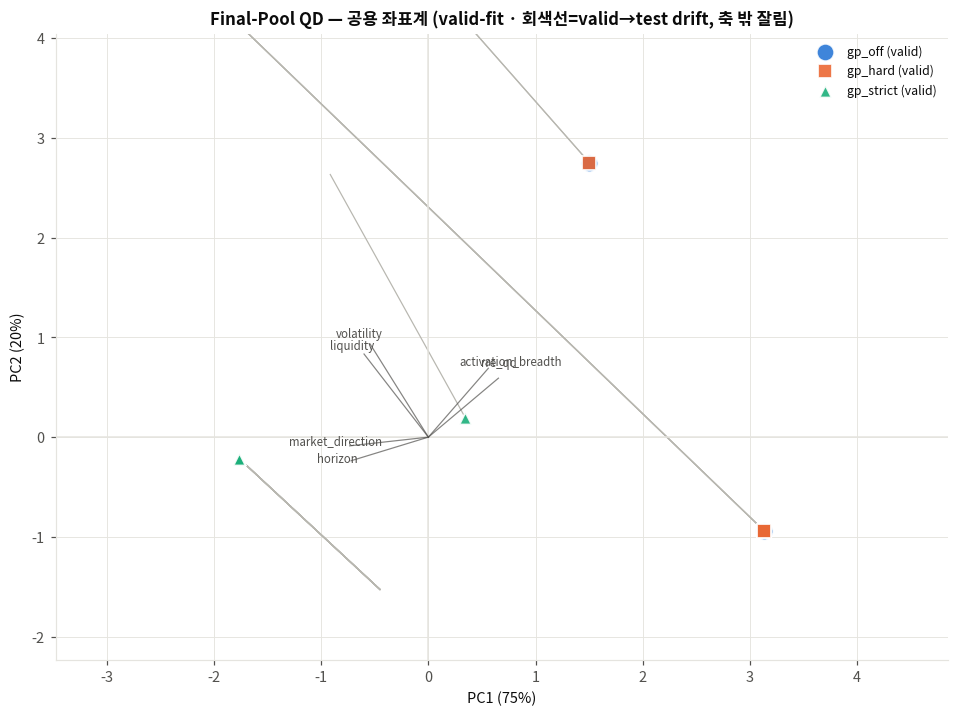

,count,mean,max
run,,,
gp_hard,3.00,10.05,10.72
gp_off,3.00,10.05,10.72
gp_strict,10.00,1.94,2.75


In [20]:
# ---------------- §7 공용 PCA (valid-fit, test-transform) ----------------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CORE = ["horizon", "volatility_response", "market_direction_response",
        "liquidity_response", "activation_breadth", "rre_qd"]
VALID_CORE = [f"valid_{c}" for c in CORE]

qall = []
for name, r in RUNS.items():
    q = r["qd_factor_descriptors"].copy()
    if q.empty:
        continue
    q.insert(0, "run", name)
    qall.append(q)
QD = pd.concat(qall, ignore_index=True)

FIT_COLS = VALID_CORE                              # §11e: valid_* 만으로 fit
assert all(c.startswith("valid_") for c in FIT_COLS)
fit_df = QD[["run", "formula"] + FIT_COLS].dropna(subset=FIT_COLS)
scaler = StandardScaler().fit(fit_df[FIT_COLS])
pca = PCA(n_components=2, random_state=0).fit(scaler.transform(fit_df[FIT_COLS]))
print(f"공용 PCA fit: {len(fit_df)}점(valid), 설명분산 {pca.explained_variance_ratio_.round(2)}")

Zv = pca.transform(scaler.transform(fit_df[FIT_COLS]))
fit_df = fit_df.assign(pc1=Zv[:, 0], pc2=Zv[:, 1])
test_ok = QD[["run", "formula"] + CORE].dropna(subset=CORE)
Zt = pca.transform(scaler.transform(test_ok[CORE].to_numpy())) if len(test_ok) else np.empty((0, 2))
test_ok = test_ok.assign(pc1=Zt[:, 0] if len(test_ok) else [], pc2=Zt[:, 1] if len(test_ok) else [])

fig, ax = plt.subplots(figsize=(8.6, 6.4), constrained_layout=True)
ax.axhline(0, color=GRID, lw=1); ax.axvline(0, color=GRID, lw=1)
merged = fit_df.merge(test_ok, on=["run", "formula"], suffixes=("_v", "_t"), how="left")
for _, x in merged.iterrows():
    if np.isfinite(x.get("pc1_t", np.nan)):
        ax.plot([x.pc1_v, x.pc1_t], [x.pc2_v, x.pc2_t], color="#b8b7b0", lw=0.8,
                zorder=1, clip_on=True)
for k, name in enumerate(RUNS):
    g = fit_df[fit_df["run"] == name]
    if g.empty:
        continue
    ax.scatter(g.pc1, g.pc2, s=130 - 34 * k, color=RUN_COLOR[name],
               marker=RUN_MARKER[name], edgecolor="white", lw=1.2,
               alpha=0.9, label=f"{name} (valid)", zorder=3 + k)
# 축 한계 = valid 점 기준 (drift 선은 잘릴 수 있음 — 제목에 명시)
xr = float(fit_df.pc1.max() - fit_df.pc1.min()) or 1.0
yr = float(fit_df.pc2.max() - fit_df.pc2.min()) or 1.0
ax.set_xlim(fit_df.pc1.min() - 0.35 * xr, fit_df.pc1.max() + 0.35 * xr)
ax.set_ylim(fit_df.pc2.min() - 0.35 * yr, fit_df.pc2.max() + 0.35 * yr)
sc = 0.32 * max(xr, yr)
for i, c in enumerate(CORE):
    vx, vy = pca.components_[0, i] * sc, pca.components_[1, i] * sc
    ax.plot([0, vx], [0, vy], color=INK2, lw=0.8, alpha=0.7, zorder=2)
    ax.annotate(c.replace("_response", ""), (vx * 1.18, vy * 1.18), color=INK2,
                fontsize=7.5, ha="center",
                va="bottom" if (i % 2 == 0) else "top")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Final-Pool QD — 공용 좌표계 (valid-fit · 회색선=valid→test drift, 축 밖 잘림)")
ax.legend(loc="best", fontsize=8)
plt.show()
# drift 크기 표 (그림 밖 정량)
if len(merged):
    merged["drift_dist"] = np.hypot(merged.pc1_t - merged.pc1_v, merged.pc2_t - merged.pc2_v)
    display(merged.groupby("run")["drift_dist"].agg(["count", "mean", "max"])
            .style.format("{:.2f}"))


## §8 ★ Descriptor-space niche analysis (원시 공간)

- bin 경계 = **모든 run의 valid descriptor 합집합(D_ref)에서 global 분위로 1회
  fit** → 모든 run×split에 동일 edges (method 간 같은 niche = 같은 실공간).
- 음영 = **valid quality (mean valid_IC_1d)**. test 값은 사후확인으로 병기
  (n / valid ̄IC / test ̄IC / test best — best 단독 표기 금지).
- 본실험에서는 pilot 이후 descriptor 정의·binning rule freeze 권고 (§12).

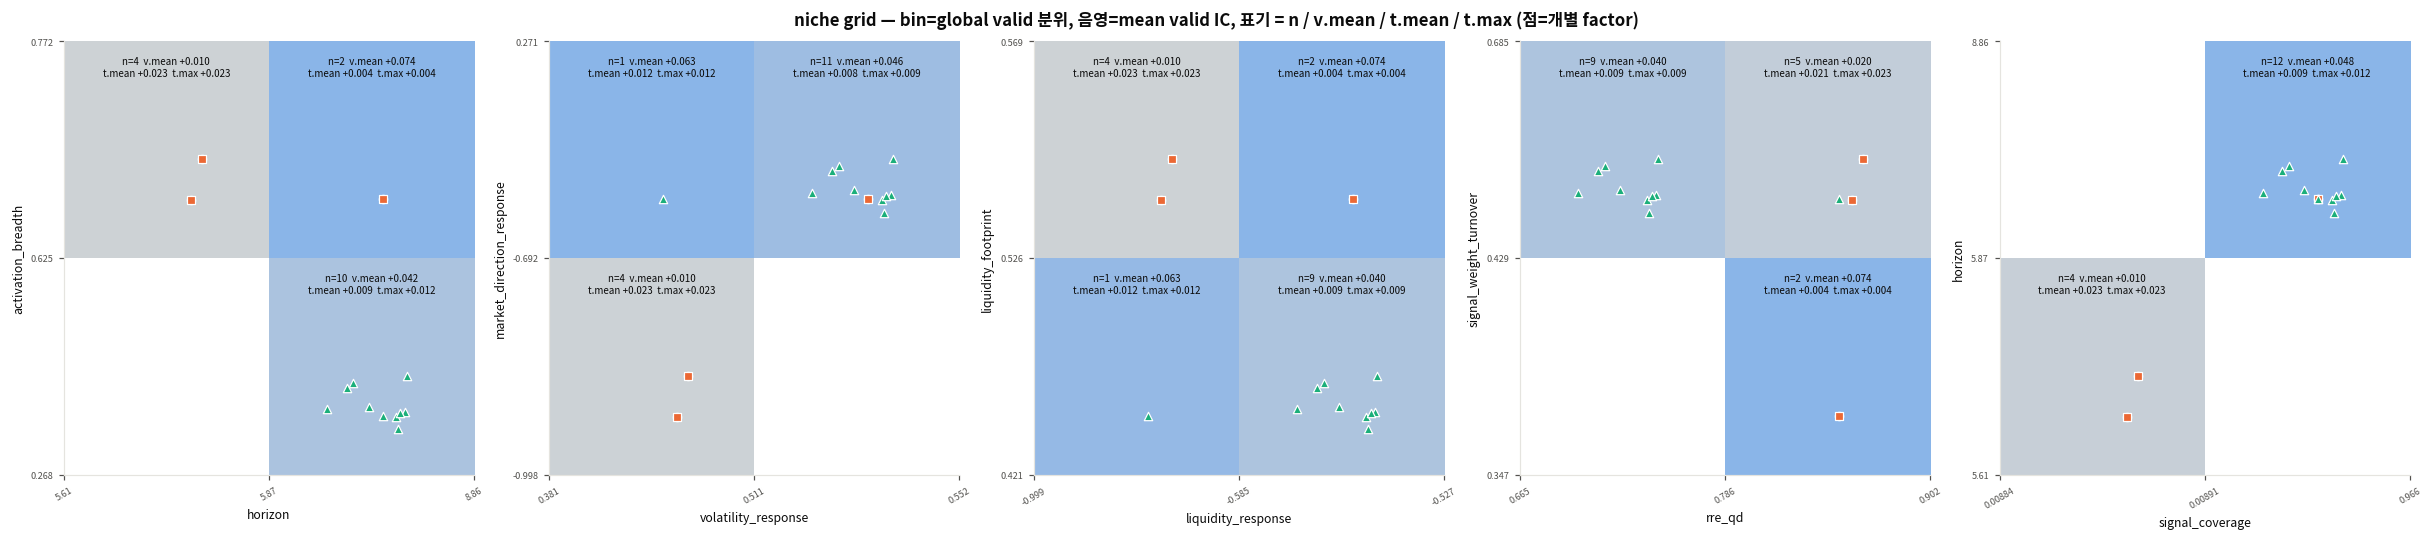

In [21]:
# ---------------- §8 niche grids ×5 ----------------
PAIRS = [("horizon", "activation_breadth"),
         ("volatility_response", "market_direction_response"),
         ("liquidity_response", "liquidity_footprint"),
         ("rre_qd", "signal_weight_turnover"),
         ("signal_coverage", "horizon")]

of_all = []
for name, r in RUNS.items():
    of = factor_rows(r, "oos_factor_metrics")
    of = of[of["valid"] == True][["formula", "IC"]].copy()           # noqa: E712
    of.insert(0, "run", name)
    of_all.append(of)
TEST_IC = pd.concat(of_all, ignore_index=True).rename(columns={"IC": "IC_test"})
NQ = QD.merge(TEST_IC, on=["run", "formula"], how="left")

def edges_from_ref(col):
    ref = NQ[f"valid_{col}"].dropna().to_numpy()      # D_ref = 전 run valid 합집합
    qs = np.linspace(0, 1, NICHE_BINS + 1)
    e = np.unique(np.nanquantile(ref, qs))
    return e if len(e) >= 3 else np.array([ref.min(), np.median(ref), ref.max()])

fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.4 * len(PAIRS), 4.8),
                         constrained_layout=True)
for ax, (cx, cy) in zip(axes, PAIRS):
    ex, ey = edges_from_ref(cx), edges_from_ref(cy)
    sub = NQ.dropna(subset=[f"valid_{cx}", f"valid_{cy}"])
    bx = np.clip(np.digitize(sub[f"valid_{cx}"], ex) - 1, 0, len(ex) - 2)
    by = np.clip(np.digitize(sub[f"valid_{cy}"], ey) - 1, 0, len(ey) - 2)
    sub = sub.assign(_bx=bx, _by=by)
    qual = np.full((len(ey) - 1, len(ex) - 1), np.nan)
    for (i, j), g in sub.groupby(["_by", "_bx"]):
        qual[i, j] = g["valid_IC_1d"].mean()
    vmax = np.nanmax(np.abs(qual)) if np.isfinite(qual).any() else 1
    ax.imshow(qual, cmap=DIV, vmin=-vmax, vmax=vmax, origin="lower", aspect="auto",
              extent=(0, len(ex) - 1, 0, len(ey) - 1), alpha=0.55)
    for (i, j), g in sub.groupby(["_by", "_bx"]):
        t = g["IC_test"].dropna()
        txt = (f"n={len(g)}  v.mean {g['valid_IC_1d'].mean():+.3f}\n"
               + (f"t.mean {t.mean():+.3f}  t.max {t.max():+.3f}" if len(t) else "t: —"))
        ax.text(j + 0.5, i + 0.93, txt, ha="center", va="top", fontsize=6.4, color=INK)
    for name in RUNS:
        g = sub[sub["run"] == name]
        if g.empty:
            continue
        jx = g["_bx"] + 0.5 + np.random.default_rng(7).uniform(-0.22, 0.22, len(g))
        jy = g["_by"] + 0.32 + np.random.default_rng(8).uniform(-0.14, 0.14, len(g))
        ax.scatter(jx, jy, s=30, color=RUN_COLOR[name], marker=RUN_MARKER[name],
                   edgecolor="white", lw=0.8, zorder=3)
    ax.set_xticks(range(len(ex)), [f"{v:.3g}" for v in ex], fontsize=6, rotation=30)
    ax.set_yticks(range(len(ey)), [f"{v:.3g}" for v in ey], fontsize=6)
    ax.set_xlabel(cx, fontsize=8); ax.set_ylabel(cy, fontsize=8)
    ax.grid(False)
fig.suptitle("niche grid — bin=global valid 분위, 음영=mean valid IC, "
             "표기 = n / v.mean / t.mean / t.max (점=개별 factor)",
             fontsize=11, fontweight="bold")
plt.show()


## §9 ★ Search-QD — budget 정규화 축

기본 x축 = **누적 attempted candidates** (GP generation·AA round는 보조 표기).
⚠️ GP generation은 재생산 population, AA round는 seed별 독립 refinement —
직접 비교 금지 (AA manifest trajectory_semantics 참조).

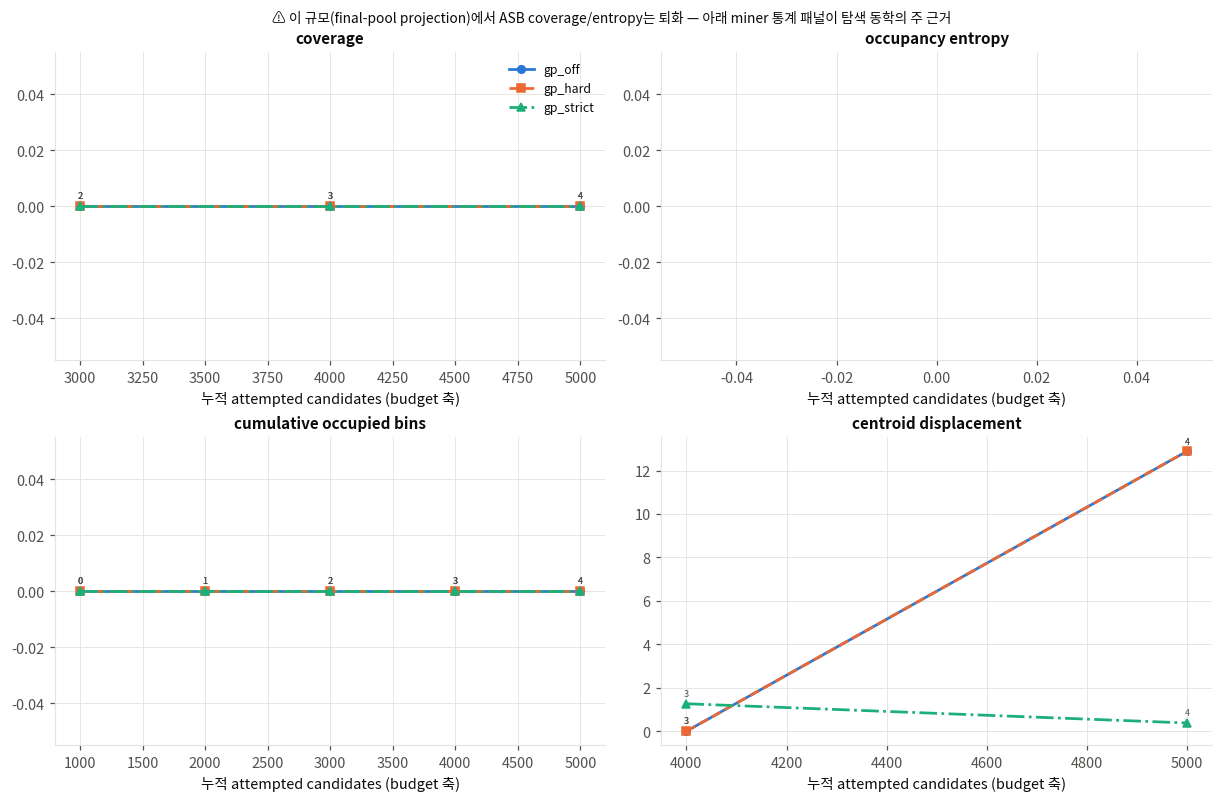

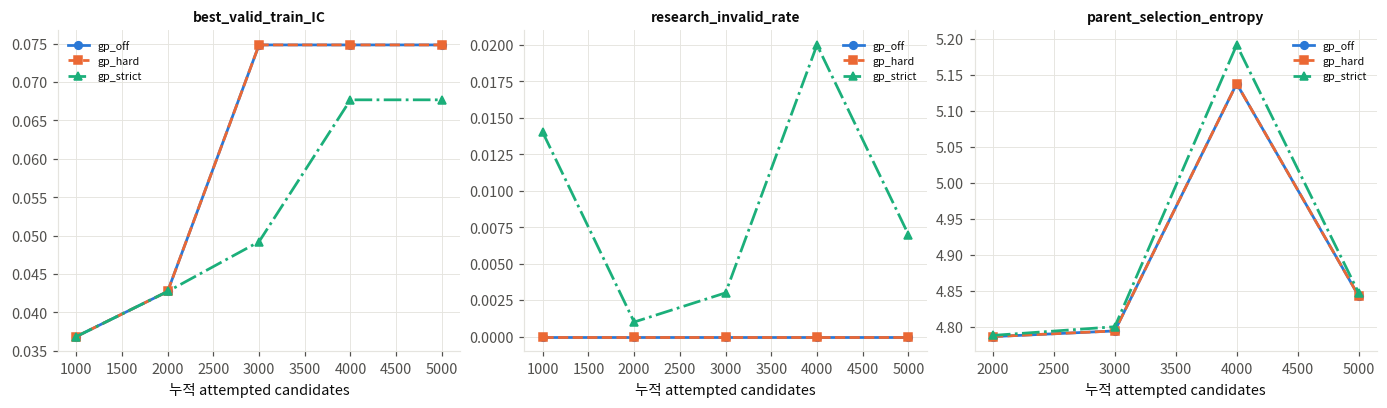

In [22]:
# ---------------- §9 search-QD ----------------
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
panels = [("coverage", "coverage"), ("occupancy_entropy", "occupancy entropy"),
          ("cumulative_occupied_bins", "cumulative occupied bins"),
          ("centroid_displacement", "centroid displacement")]
for name, r in RUNS.items():
    gm = r["qd_generation_metrics"]
    if gm.empty:
        continue
    xb = gm["n_candidates"].cumsum()
    for ax, (col, ttl) in zip(axes.flat, panels):
        if col not in gm:
            continue
        ax.plot(xb, gm[col], lw=1.8, color=RUN_COLOR[name], ls=RUN_LS[name],
                marker=RUN_MARKER[name], ms=5, label=name)
        for xi, yi, gi in zip(xb, gm[col], gm["generation"]):
            ax.annotate(str(int(gi)), (xi, yi), fontsize=6, color=INK2,
                        xytext=(0, 5), textcoords="offset points", ha="center")
for ax, (col, ttl) in zip(axes.flat, panels):
    ax.set_title(ttl, fontsize=10)
    ax.set_xlabel("누적 attempted candidates (budget 축)")
axes.flat[0].legend(fontsize=8)
_maxcov = max((float(r["qd_generation_metrics"]["coverage"].max())
               for r in RUNS.values() if not r["qd_generation_metrics"].empty
               and "coverage" in r["qd_generation_metrics"]), default=0)
if _maxcov < 0.01:
    fig.suptitle("⚠ 이 규모(final-pool projection)에서 ASB coverage/entropy는 퇴화 — "
                 "아래 miner 통계 패널이 탐색 동학의 주 근거", fontsize=9, y=1.02)
plt.show()

# miner 통계 (있으면): elite-capture 서사 — best valid IC vs invalid rate vs 다양성
have = {n: r["miner_gen_stats"] for n, r in RUNS.items() if not r["miner_gen_stats"].empty}
if have:
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), constrained_layout=True)
    for name, gs in have.items():
        if "generation" in gs:            # gplearn generation_stats
            xb = gs["population_size"].cumsum() if "population_size" in gs else gs["generation"]
            trio = [("best_valid_train_IC", 0), ("research_invalid_rate", 1),
                    ("parent_selection_entropy", 2)]
        else:                              # AA round_stats
            xb = gs["n_candidates"].cumsum()
            trio = [("mean_abs_feedback_IC", 0), ("n_feedback_error", 1),
                    ("mean_similarity", 2)]
        for col, k in trio:
            if col in gs:
                axes[k].plot(xb, gs[col], lw=1.8, color=RUN_COLOR[name],
                             ls=RUN_LS[name], marker=RUN_MARKER[name], ms=5,
                             label=name)
                axes[k].set_title(col, fontsize=9)
                axes[k].set_xlabel("누적 attempted candidates")
    for ax in axes:
        ax.legend(fontsize=7)
    plt.show()


## §10 ★ Statistical comparison — 계층적 규칙

| n_seeds | 표시 |
|---|---|
| <3 | raw points + 기술통계만 (검정·CI 없음) |
| 3–4 | + mean/std + bootstrap CI (**exploratory — 참고용** 라벨 강제) |
| ≥5 | + bootstrap 95% CI + Cliff's delta |
| 충분 | + paired test (공유 seed) |

⚠️ n_seeds<3 — raw point + 기술통계만 (inferential claim 금지)


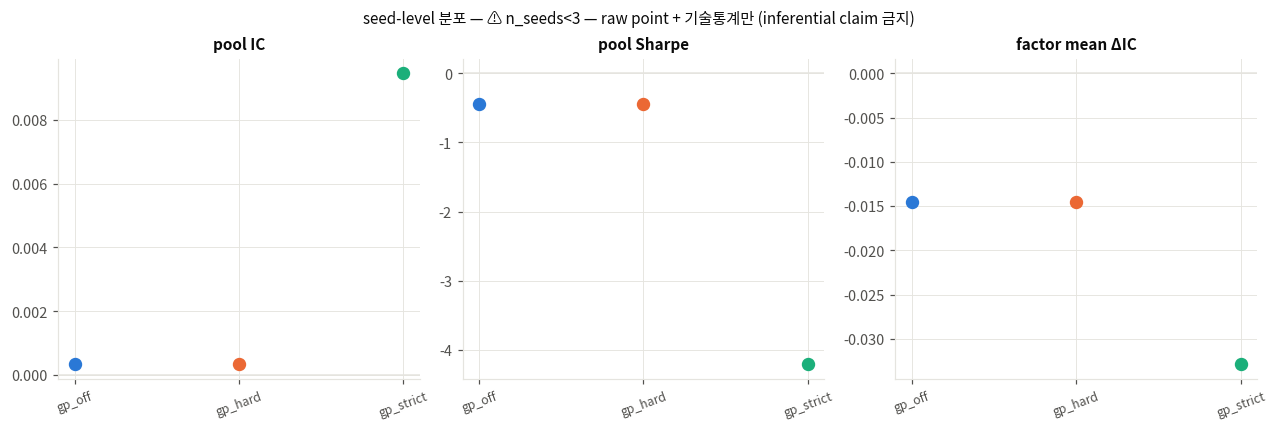

,,seed,pool IC,pool Sharpe,factor mean ΔIC
group,run,,,,
gp_off,gp_off,42,+0.0003,-0.4479,-0.0145
gp_hard,gp_hard,42,+0.0003,-0.4479,-0.0145
gp_strict,gp_strict,42,+0.0095,-4.2022,-0.0329


In [23]:
# ---------------- §10 seed-level 통계 (자동 강등) ----------------
def stat_tier(n):
    return ("desc" if n < 3 else "explore" if n <= 4 else "ci")

pts = []
for name, r in RUNS.items():
    seed = r["miner_manifest"].get("seed", r["manifest"].get("seed"))
    row = {"group": r["group"], "run": name, "seed": seed,
           "pool IC": pget(r, "oos_pool_metrics", "IC"),
           "pool Sharpe": pget(r, "backtest_pool_metrics", "Sharpe")}
    g = GEN[GEN["run"] == name]
    row["factor mean ΔIC"] = g["dIC"].mean() if len(g) else np.nan
    pts.append(row)
PTS = pd.DataFrame(pts)
NSEED = PTS.groupby("group")["seed"].nunique()
tier = stat_tier(int(NSEED.max()))
banner = {"desc": "⚠️ n_seeds<3 — raw point + 기술통계만 (inferential claim 금지)",
          "explore": "bootstrap CI는 exploratory(참고용) — inferential claim 금지",
          "ci": "bootstrap 95% CI + effect size 표시"}[tier]
print(banner)

metrics3 = ["pool IC", "pool Sharpe", "factor mean ΔIC"]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), constrained_layout=True)
groups = list(dict.fromkeys(PTS["group"]))
for ax, mcol in zip(axes, metrics3):
    for gi, grp in enumerate(groups):
        g = PTS[PTS["group"] == grp]
        ax.scatter([gi] * len(g), g[mcol], s=60,
                   color=RUN_COLOR[g["run"].iloc[0]], zorder=3)
        if tier != "desc" and g[mcol].notna().sum() >= 3:
            bs = [np.nanmean(np.random.default_rng(s).choice(
                g[mcol].dropna(), size=len(g), replace=True)) for s in range(2000)]
            lo, hi = np.percentile(bs, [2.5, 97.5])
            ax.plot([gi, gi], [lo, hi], color=INK2, lw=2, alpha=0.7)
    ax.set_xticks(range(len(groups)), groups, rotation=20, fontsize=8)
    ax.axhline(0, color=GRID, lw=1)
    ax.set_title(mcol, fontsize=10)
fig.suptitle(f"seed-level 분포 — {banner}", fontsize=10)
plt.show()
display(PTS.set_index(["group", "run"]).style.format("{:+.4f}", subset=metrics3, na_rep="—"))


## §11 ★ Robustness / consistency assertions

아래 셀이 실패하면 노트북 전체가 실패한다 — 육안검사와 별개의 자동 검증층.

In [24]:
# ---------------- §11 assertions ----------------
import sys as _sys
_sys.path.insert(0, str(ASB_ROOT))
from alphasearchbench.backtest.metrics import performance_metrics   # ASB 의미론 그대로

report = []
for name, r in RUNS.items():
    # (a) pool daily → ASB metrics 함수로 재계산 == 저장값 (자체 공식 재구현 금지)
    bp = pool_row(r, "backtest_pool_metrics")
    bd = r["bt_daily"]
    if bp is not None and not bd.empty:
        pid_rows = bd[bd["formula_id"].astype(str).str.contains(":")]
        if len(pid_rows):
            rec = performance_metrics(pid_rows.sort_values("date"))
            for k in ("CAGR", "Sharpe", "MDD", "AnnRet_arith"):
                if k in rec and pd.notna(bp.get(k)):
                    assert np.isclose(rec[k], bp[k], rtol=1e-6, atol=1e-9), \
                        f"{name}: {k} 재계산 {rec[k]} != 저장 {bp[k]}"
            report.append(f"{name}: (a) pool 지표 재계산 일치")
    # (b) train_sign == sign(signed_train_IC)
    of = factor_rows(r, "oos_factor_metrics")
    ok = of[of["valid"] == True]                                     # noqa: E712
    if len(ok):
        s = np.where(ok["signed_train_IC"] >= 0, 1, -1)
        assert (s == ok["train_sign"]).all(), f"{name}: train_sign 불일치"
        report.append(f"{name}: (b) sign 규약 일치")
    # (d) 단계별 eligible set — unexpected exclusion만 금지
    v = r["validity_factor_metrics"]
    base = set(v["formula"])
    gate_pass = set(v[v["valid"] == True]["formula"])                # noqa: E712
    expected_excl = base - gate_pass                                 # 사유: invalid_reason
    oos_have = set(ok["formula"])
    unexpected = gate_pass - oos_have
    assert not unexpected, f"{name}: OOS 단계 무사유 유실 {unexpected}"
    qd_have = set(r["qd_factor_descriptors"]["formula"])
    unexpected_qd = gate_pass - qd_have
    assert not unexpected_qd, f"{name}: QD 단계 무사유 유실 {unexpected_qd}"
    report.append(f"{name}: (d) join 무사유 유실 0 (의도 제외 {len(expected_excl)}건)")
# (e) §7 fit 입력 valid_* 만 — 구조적 재확인
assert all(c.startswith("valid_") for c in FIT_COLS)
report.append("(e) PCA fit 입력 = valid_* 전용")
# (c)는 §2에서, (f)는 §1에서 이미 assert됨
report.append("(c) leakage — §2에서 통과 / (f) 재로딩 결정론 — §1에서 통과")
print("\n".join(report))
print("\n✅ §11 assertions 전부 통과")


gp_off: (a) pool 지표 재계산 일치
gp_off: (b) sign 규약 일치
gp_off: (d) join 무사유 유실 0 (의도 제외 0건)
gp_hard: (a) pool 지표 재계산 일치
gp_hard: (b) sign 규약 일치
gp_hard: (d) join 무사유 유실 0 (의도 제외 0건)
gp_strict: (a) pool 지표 재계산 일치
gp_strict: (b) sign 규약 일치
gp_strict: (d) join 무사유 유실 0 (의도 제외 0건)
(e) PCA fit 입력 = valid_* 전용
(c) leakage — §2에서 통과 / (f) 재로딩 결정론 — §1에서 통과

✅ §11 assertions 전부 통과


## §12 Interpretation & limitations

- **pool 지표는 equal weights(참고용)** — 마이닝이 학습한 weights가 아님
  (§2 weights 열 확인).
- **n_seeds=1 (pilot)** — §10은 기술 통계만. method 우열 주장은 seed sweep 후.
- **per-candidate descriptor 미저장** — §8 niche는 final-pool 범위. 본실험
  권고: attempted 후보 전체 descriptor 덤프(ASB 확장) → sampling distribution
  / mode collapse / revisitation 측정 가능.
- **AA round ≠ GP generation** — §9는 budget 축으로 정렬했으나 집단 진화 vs
  독립 refinement라는 구조 차이는 남는다.
- **binning rule freeze 권고** — §8 bin 경계는 이 pilot의 valid 분포에서 fit.
  본실험에서는 사전 고정할 것.
- **test 노출 이력**: validity threshold(0.05/30/0.90)는 과거 파일럿에서
  train/valid 분포로 재도출되었으나 test 관찰 이력이 있음 — 최종 판정은
  새 seed set으로.
